# Phase 6 - S/M/L Rhythm Encoding

**Goal**: convert intervals between events into discrete symbols (S,M,L) so we can anayze rhythmic patterns as sequences.

Symbols:
- S(short): interval < 0.25 sec (rapid succession, "ta-ta")
- M (Medium): 0.25 <= interval < 0.8 sec
- L (Long): interval >= 0.80 sec (clear pause , "taaan")

Common bigrams/trigrams reveal rhythmic gestures:
- S-L = ta-tan
- S-S-L = ta-ta-tan
- L-L-L = repetitive 

## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

DATA_CLEAN_DIR = '../data_clean'
df = pd.read_csv(os.path.join(DATA_CLEAN_DIR, 'all_events_clustered.csv'))
df = df.sort_values('t_rel').reset_index(drop=True)
print(f'Loaded {len(df):,} events')

Loaded 4,312 events


## 6.1 Symbol assignment

In [2]:
S_THRESHOLD = 0.25
M_THRESHOLD = 0.80

def interval_to_sml(dt, s_thr=S_THRESHOLD, m_thr=M_THRESHOLD):
    if dt < s_thr:
        return 'S'
    elif dt < m_thr:
        return 'M'
    else:
        return 'L'

# Compute symbols from IEI
ieis = np.diff(df['t_rel'].values)
symbols = [interval_to_sml(x) for x in ieis]

# Add to df (with placeholder for first row)
df['sml'] = ['?'] + symbols

print('Symbol distribution (all events):')
print(pd.Series(symbols).value_counts(normalize=True).round(3))

Symbol distribution (all events):
M    0.485
L    0.408
S    0.107
Name: proportion, dtype: float64


## 6.2 Visusalize threshold Choice 

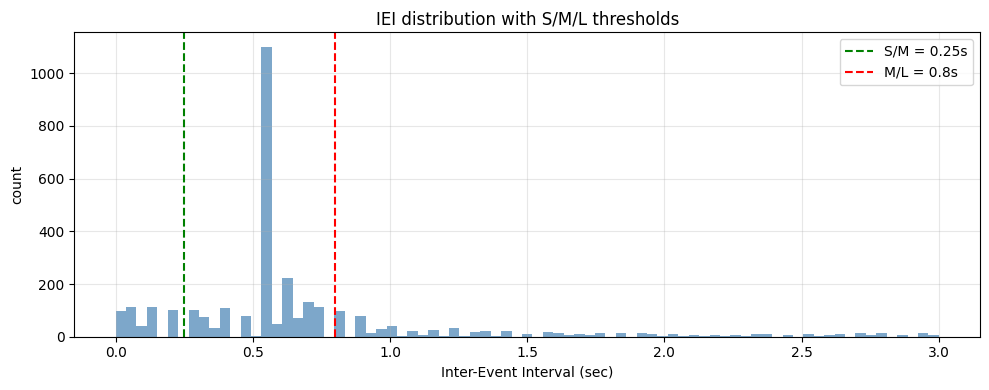

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ieis, bins=np.linspace(0, 3, 80), color='steelblue', alpha=0.7)
ax.axvline(S_THRESHOLD, color='green',  linestyle='--', label=f'S/M = {S_THRESHOLD}s')
ax.axvline(M_THRESHOLD, color='red',    linestyle='--', label=f'M/L = {M_THRESHOLD}s')
ax.set_xlabel('Inter-Event Interval (sec)')
ax.set_ylabel('count')
ax.set_title('IEI distribution with S/M/L thresholds')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/18_sml_thresholds.png', dpi=120)
plt.show()

It's strange that there is one large bar around 0.5 ... 
I think it reflects the deduplication in phase 1. 
Since I wanted to count bubbles in the same area that happened within 0.5 second as the same bubble, lots of bubbles captured in sequence was calculated as "the next bubble popped up 0.5 seconds after the previous bubble that is captured around the same area"

Although M is large because of the above, I think it's okay since the point is to capture the rhythm that frequently appears in each k-mean cluster by using the time group (S/M/L), and the time group should be decided purely by the aesthetic perspectives. (How is it sound like)

## 6.3 Pattern counts

In [4]:
# Bigrams (pairs of consecutive symbols)
bigrams = list(zip(symbols[:-1], symbols[1:]))
bigram_counts = Counter(bigrams)

print('Top 9 bigrams:')
for (s1, s2), n in bigram_counts.most_common(9):
    print(f'  {s1}-{s2}: {n:>6,} ({n/len(bigrams)*100:.1f}%)')

Top 9 bigrams:
  M-M:  1,258 (29.2%)
  L-L:    996 (23.1%)
  M-L:    646 (15.0%)
  L-M:    631 (14.6%)
  S-M:    200 (4.6%)
  M-S:    185 (4.3%)
  S-S:    144 (3.3%)
  L-S:    133 (3.1%)
  S-L:    117 (2.7%)


In [5]:
# Trigrams (triples)
trigrams = list(zip(symbols[:-2], symbols[1:-1], symbols[2:]))
trigram_counts = Counter(trigrams)

print('Top 15 trigrams:')
for (s1, s2, s3), n in trigram_counts.most_common(15):
    print(f'  {s1}-{s2}-{s3}: {n:>6,} ({n/len(trigrams)*100:.1f}%)')

Top 15 trigrams:
  M-M-M:    801 (18.6%)
  L-L-L:    576 (13.4%)
  M-M-L:    374 (8.7%)
  L-M-M:    361 (8.4%)
  L-L-M:    360 (8.4%)
  M-L-L:    359 (8.3%)
  L-M-L:    228 (5.3%)
  M-L-M:    228 (5.3%)
  M-S-M:    115 (2.7%)
  S-M-M:     96 (2.2%)
  S-S-S:     91 (2.1%)
  M-M-S:     83 (1.9%)
  S-L-L:     61 (1.4%)
  L-L-S:     60 (1.4%)
  S-M-S:     60 (1.4%)


## 6.4 Bigram heatmap

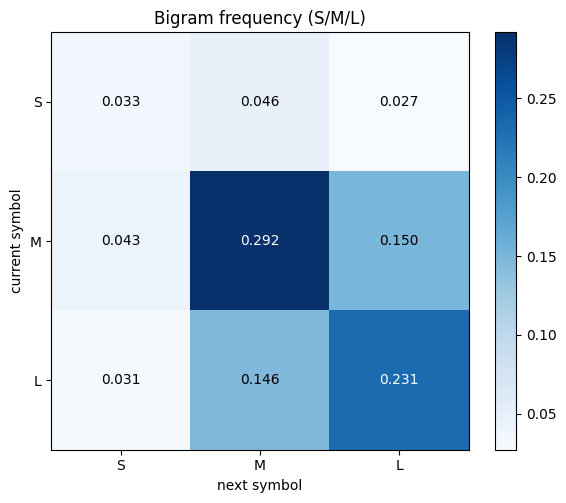

In [6]:
sml = ['S', 'M', 'L']
matrix = np.zeros((3, 3))
for i, s1 in enumerate(sml):
    for j, s2 in enumerate(sml):
        matrix[i, j] = bigram_counts.get((s1, s2), 0)
matrix_norm = matrix / matrix.sum()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix_norm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(sml)
ax.set_yticks(range(3)); ax.set_yticklabels(sml)
ax.set_xlabel('next symbol')
ax.set_ylabel('current symbol')
ax.set_title('Bigram frequency (S/M/L)')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{matrix_norm[i,j]:.3f}',
                ha='center', va='center',
                color='white' if matrix_norm[i,j] > 0.15 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('../outputs/plots/19_bigram_heatmap.png', dpi=120)
plt.show()

### Findings
The heatmap seems to be influenced a lot by the number of Ms
<br> - but it's still interesting to see L-L happens relatively high despite the small representation of L.

## 6.5 Save

In [7]:
out = os.path.join(DATA_CLEAN_DIR, 'all_events_sml.csv')
df.to_csv(out, index=False)
print(f'Saved: {out}')

Saved: ../data_clean/all_events_sml.csv
